Python Notebook to implement MASC algorithm on Salinas dataset.

# Import Packages

In [1]:
import numpy as np
import random
import pandas as pd
from scipy import stats
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.special import jacobi
from scipy.special import loggamma
import copy
from sklearn import metrics
import csv
import scipy

# Import and Setup Data

In [2]:
with open("train_salinas_half_10class.csv", 'r') as x:
    sample_data = list(csv.reader(x, delimiter=","))
train = np.array(sample_data)[1:20035].astype(float)
print(train,np.shape(train))

[[ 1.99979847 -0.72274509 -1.22112664 ...  0.52875176 -1.55042951
   0.87423872]
 [ 1.80382465 -0.40759556 -1.04130601 ...  0.97428594  0.48191141
   1.10969247]
 [ 1.93074712 -0.55734316 -1.28452244 ... -0.9156962   0.43583374
  -0.65388899]
 ...
 [-0.94668587 -0.98060242 -0.45060834 ...  1.4347525   0.25964165
   0.25810408]
 [-0.92210224 -0.84821505 -0.32175008 ... -2.32313729  0.01304315
  -0.09601455]
 [-0.89657975 -0.77119052 -0.26675822 ...  1.0386675   1.95054709
   1.50077064]] (20034, 50)


In [3]:
with open("target_salinas_half_10class.csv", 'r') as x:
    sample_data = list(csv.reader(x, delimiter=","))
 
target = np.array(sample_data)[1:20035].reshape((20034,)).astype(int)
print(np.shape(target))


(20034,)


Get size of training set and classes. Print number of points belonging to each class.

In [4]:
trainsize=len(train[:,0])
classes=np.sort(list(dict.fromkeys(target)))
print(f"Vector of class labels: {classes}")
for i in np.arange(1,11):
    print(f"Number of points in class {i}: {len(np.where(target==i)[0])}")

Vector of class labels: [ 1  2  3  4  5  6  7  8  9 10]
Number of points in class 1: 1004
Number of points in class 2: 1863
Number of points in class 3: 988
Number of points in class 4: 697
Number of points in class 5: 1339
Number of points in class 6: 1979
Number of points in class 7: 1789
Number of points in class 8: 5635
Number of points in class 9: 3101
Number of points in class 10: 1639


Define Data matrices on the sphere.

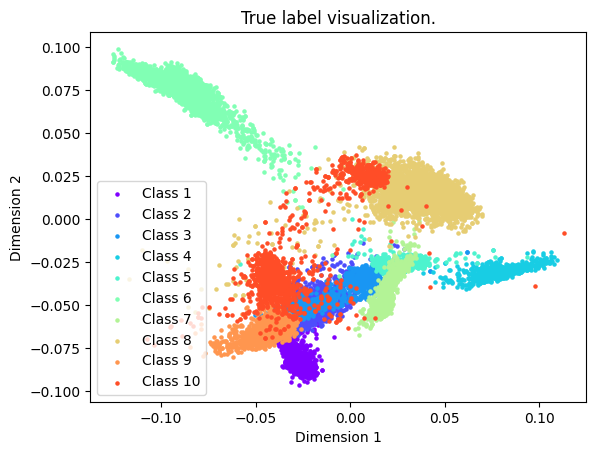

In [5]:
# #Translate Training Data to have range centered at zero
avg=(np.max(train, axis=0)+np.min(train, axis=0))/2
traincen=train-avg

#traincen=svdtrain

#Project Data to the sphere with hyperparameter alpha in (0,2]
alpha=1
maxnorm=np.max(np.linalg.norm(traincen, axis=1))
scaledtrain=alpha*traincen/maxnorm #1.5 can be changed to any value <=2 to control spread of data
r=np.linalg.norm(scaledtrain, axis=1)
trainsph=np.hstack((((4*(scaledtrain.T*r).T).T/((4+r**2)*r)).T,((4-r**2)/(4+r**2)).reshape(trainsize,1)))
normsph=np.linalg.norm(trainsph, axis=1)

#Matrix of angles between points
sphmat=np.matmul(trainsph,np.transpose(trainsph))
#this line is for slight rounding error causing out-of-bounds for arccos
sphmat[sphmat>1]=1

#Matrix of spherical distance between points
distmat=np.arccos(sphmat)
# print(sphmat.max(),sphmat.min())
# print(distmat.max(),distmat.min())

c=cm.rainbow(np.linspace(0,1,len(classes)+1))
for i in classes:
    plt.scatter(trainsph[np.where(target==i)[0],1],trainsph[np.where(target==i)[0],2],s=5,color=c[i-1],label=f"Class {i}")
plt.title('True label visualization.')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.show()

# Define Localized Kernels

Positive Chebyshev Kernel for use with support estimation. Included is a piecewise linear estimation of the kernel for improved run-times.

In [6]:
#defining the half-pass filter
def h(t):
    t = np.abs(t)
    out = np.zeros_like(t)
    for i in range(len(t)):
        if t[i] <= 1/2:
            out[i] = 1
        elif (1/2 < np.abs(t[i])) and (np.abs(t[i]) < 1):
            out[i] = np.exp(-np.exp(2/(1-2*t[i]))/(1-t[i]))
        else:
            out[i] = 0
    return out

#Phi Kernel Definition
def Phi(n,x):
    out=1/(2*np.pi)
    for k in np.arange(1,n,1):
        out+=h([k/n])*np.cos(k*np.arccos(x))/np.pi
    out=out**2
    return out

#linear interpolation approximation to kernel function
def Phiapprox(n,x,numinterp):
    xdir=x.shape[0]
    if x.ndim==1:
        ydir=1
    if x.ndim==2:
        ydir=x.shape[1]
    xlist=np.vstack((x.reshape(1,xdir*ydir),np.arange(xdir*ydir)))
    phivals=1-2*(1/2-np.linspace(-1,1,numinterp)/2)**(n/2)
    phivec=Phi(n,phivals)
    newmat=np.zeros((xdir*ydir,1))
    for i in np.arange(1,numinterp,1):
        ind=xlist[0]<=phivals[i]
        newmat[xlist[1][ind].astype(int)]=(phivec[i-1]+(xlist[0][ind]-phivals[i-1])*(phivec[i]-phivec[i-1])/(phivals[i]-phivals[i-1])).reshape(ind.sum(),1)
        xlist=np.delete(xlist, ind, 1)
    newmat=np.reshape(newmat,(xdir,ydir))
    return newmat

# MASC Algorithm

Generate Phimat matrix for thresholding and querying.

In [7]:
n=128

Phimat=Phiapprox(n,sphmat,100)
Phisum=np.sum(Phimat,axis=0)

Theta thresholding.

In [8]:
Theta=.4

#percentage of data to be captured
datathreshold=.85
verticescount=0

while verticescount<datathreshold*trainsize:
    Theta=Theta-.005
    vertex_list=np.where(Phisum>Theta*Phisum.max())[0]
    verticescount=len(vertex_list)
    

#distmat for only those points
distmat_sheared=(distmat[vertex_list].T[vertex_list]).T
print(Theta)
print(verticescount)

0.35
17632


Eta for loop of MASC algorithm, with KNN extension calculated for several values in order to show accuracy/#queries information for purposes of plots in the paper. Run time can be improved by only running KNN extension once after the eta loop is done.

In [10]:
predict_labels=np.zeros(trainsize)
A=[]
B=[]
indlist=[]

querycount=0
numqueries=[]
MASClist=[]

def Knearest(X,label,K):
    indmat=np.argpartition(-X, K, axis=0)[:K]
    labelsmasked=label[indmat]
    return scipy.stats.mode(labelsmasked, keepdims=True)[0]

for eta in np.arange(.21,.27,.005):
    #Adjacency matrix for sheared points
    adjmat=np.zeros([verticescount, verticescount])
    adjmat[distmat_sheared<eta]=1
    adjmat=adjmat-np.identity(len(vertex_list))

    #Compute Graph components
    graph=csr_matrix(adjmat)
    num_components, componentlist = connected_components(csgraph=graph, directed=False, return_labels=True)

    #Trim components. Any components of size smaller than this value will be removed from list by setting their component to -1
    componentthreshold=3
    componentnum, componentsizes=np.unique(componentlist, return_counts="True")
    bigcomponents=np.where(componentsizes>componentthreshold)[0]
    sheared_componentlist=componentlist[np.isin(componentlist,bigcomponents)]
    sheared_componentnum, sheared_componentsizes=np.unique(sheared_componentlist, return_counts="True")

    #Find modal points in each cluster to query true class label. keep track of x_i and y_i from each.
    for i in sheared_componentnum: # np.arange(0,num_components):
        componentset=vertex_list[np.where(componentlist==i)[0]]
        if np.intersect1d(A,componentset).size==0:

            x_i=componentset[np.argmax(Phisum[componentset])]
            y_i=target[x_i]
            A.append(x_i)
            B.append(y_i)
            predict_labels[componentset]=y_i
            
        elif np.size(np.unique(np.intersect1d(A,componentset)))==1:
            predict_labels[componentset]=target[np.unique(np.intersect1d(A,componentset))[0]]

    if len(A)>querycount+5:
        querycount=len(A)
        labels=copy.deepcopy(predict_labels)
        predict_labels_ind=np.where(predict_labels)[0]
        indlist.append(predict_labels_ind)
        extensionmat=sphmat[predict_labels_ind,:]
        extensionmat=extensionmat[:,np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]
        newlabels=Knearest(extensionmat,labels[predict_labels_ind],25)
        labels[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]=newlabels

        truthcheck3=target==labels
        correctnum3=len(np.where(truthcheck3)[0])
        print(f"Number of correctly classified points and queries: {correctnum3} ({100*correctnum3/trainsize:.2f}%), {len(A)}")
        MASClist.append(correctnum3/trainsize)
        numqueries.append(len(A))
            


predict_labels_ind=np.where(predict_labels)[0]
truthcheck=target[predict_labels_ind].T==predict_labels[predict_labels_ind]


predict_labels_ind=np.where(predict_labels)[0]
truthcheck=target[predict_labels_ind]==predict_labels[predict_labels_ind]
correctnum=len(np.where(truthcheck)[0])
totalnum=len(predict_labels_ind)

print(f"List of classes in the prediction: {np.setdiff1d(list(dict.fromkeys(predict_labels)),[0])}")
print(f"Number of points queried: {len(A)}")
print(f"Number of points classified: {totalnum}")
print(f"Number of correctly classified points of those classified: {correctnum} ({100*correctnum/totalnum:.2f}%)")

labels=copy.deepcopy(predict_labels)
predict_labels_ind=np.where(predict_labels)[0]
extensionmat=sphmat[predict_labels_ind,:]
extensionmat=extensionmat[:,np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]
newlabels=Knearest(extensionmat,labels[predict_labels_ind],25)
labels[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]=newlabels

truthcheck3=target==labels
correctnum3=len(np.where(truthcheck3)[0])
print(f"Number of correctly classified points and queries: {correctnum3} ({100*correctnum3/trainsize:.2f}%), {len(A)}")
MASClist.append(correctnum3/trainsize)
numqueries.append(len(A))

Number of correctly classified points and queries: 5893 (29.41%), 11
Number of correctly classified points and queries: 8701 (43.43%), 20
Number of correctly classified points and queries: 12120 (60.50%), 36
Number of correctly classified points and queries: 14590 (72.83%), 52
Number of correctly classified points and queries: 15637 (78.05%), 85
Number of correctly classified points and queries: 16006 (79.89%), 122
Number of correctly classified points and queries: 17405 (86.88%), 152
Number of correctly classified points and queries: 18142 (90.56%), 175
Number of correctly classified points and queries: 18546 (92.57%), 198
Number of correctly classified points and queries: 18991 (94.79%), 214
Number of correctly classified points and queries: 19318 (96.43%), 231
Number of correctly classified points and queries: 19354 (96.61%), 239
Number of correctly classified points and queries: 19454 (97.10%), 247
List of classes in the prediction: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Number 

In [11]:
print(numqueries)
print(MASClist)

[11, 20, 36, 52, 85, 122, 152, 175, 198, 214, 231, 239, 247, 247]
[0.2941499450933413, 0.43431167016072675, 0.6049715483677748, 0.728261954677049, 0.7805231107117899, 0.798941798941799, 0.8687730857542179, 0.905560547069981, 0.9257262653489069, 0.9479385045422781, 0.9642607567135869, 0.9660577019067585, 0.9710492163322352, 0.9710492163322352]


Plot output from MASC algorithm before KNN extension.

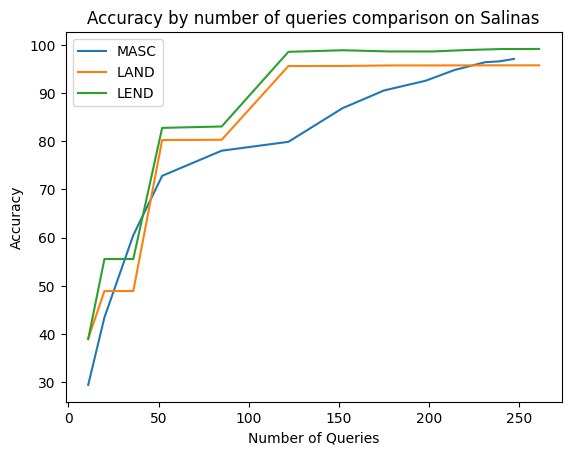

In [ ]:
plt.plot(numqueries,[i*100 for i in MASClist],label="MASC")
plt.title('Accuracy by number of queries comparison on Salinas')
plt.xlabel('Number of Queries')
plt.ylabel('Accuracy')
oldpoints=[11, 20, 36, 52, 85, 122, 152, 178, 202, 221, 240, 254, 261]

landlist=[0.39008685235100327, 0.489068583408206, 0.489068583408206, 0.8026854347609065, 0.8031845862034541, 0.956324248777079, 0.9564739942098432, 0.9575222122391933, 0.9575721273834481, 0.9576719576719577, 0.9577218728162125, 0.9578217031047219, 0.9578217031047219]
lendlist=[0.389288210042927, 0.5555555555555556, 0.5556054706998104, 0.8278925826095638, 0.8307876609763403, 0.9858240990316463, 0.9891184985524608, 0.9866227413397225, 0.9865728261954677, 0.9896176499950085, 0.9916142557651991, 0.9917140860537087, 0.991863831486473]

# landlist=[0.39008685235100327, 0.489068583408206, 0.489068583408206, 0.8026854347609065, 0.8031845862034541, 0.956324248777079, 0.9564739942098432, 0.9575222122391933, 0.9575721273834481, 0.9576719576719577, 0.9577218728162125, 0.9578217031047219]
# lendlist=[0.389288210042927, 0.5555555555555556, 0.5556054706998104, 0.8278925826095638, 0.8307876609763403, 0.9858240990316463, 0.9891184985524608, 0.9866227413397225, 0.9865728261954677, 0.9896176499950085, 0.9916142557651991, 0.9917140860537087]
plt.plot(oldpoints,[i*100 for i in landlist],label="LAND")
plt.plot(oldpoints,[i*100 for i in lendlist],label="LEND")
plt.legend()

<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ryanm\AppData\Local\Temp\ipykernel_31796\289294426.py:7: SyntaxWarning: invalid escape sequence '\T'
  plt.title(f'Visualization of classification with n: {n}, $\Theta$: {Theta:.2f}, $\eta\in [0.21,0.27]$.\n {len(A)} points queried. {totalnum}/{trainsize} points classified. \n {correctnum}/{totalnum} ({100*correctnum/totalnum:.2f}%) classified correctly.')
C:\Users\ryanm\AppData\Local\Temp\ipykernel_31796\289294426.py:7: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Visualization of classification with n: {n}, $\Theta$: {Theta:.2f}, $\eta\in [0.21,0.27]$.\n {len(A)} points queried. {totalnum}/{trainsize} points classified. \n {correctnum}/{totalnum} ({100*correctnum/totalnum:.2f}%) classified correctly.')


18587


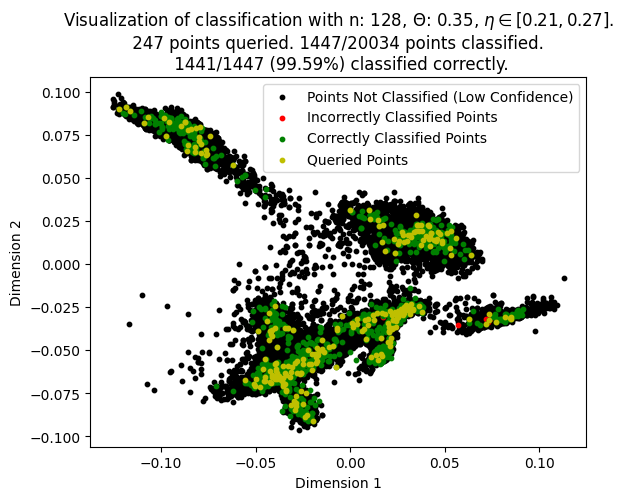

In [13]:
falsepoints=predict_labels_ind[np.where(truthcheck==False)[0]]
truepoints=predict_labels_ind[np.where(truthcheck)[0]]
plt.scatter(trainsph[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind),1],trainsph[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind),2],s=10,color="black", label=f"Points Not Classified (Low Confidence)")
plt.scatter(trainsph[falsepoints,1],trainsph[falsepoints,2],s=10,color="r",label=f"Incorrectly Classified Points")
plt.scatter(trainsph[np.setdiff1d(truepoints,A),1],trainsph[np.setdiff1d(truepoints,A),2],color="g",s=10,label=f"Correctly Classified Points")
plt.scatter(trainsph[A,1],trainsph[A,2],color="y",s=10,label=f"Queried Points")
plt.title(f'Visualization of classification with n: {n}, $\Theta$: {Theta:.2f}, $\eta\in [0.21,0.27]$.\n {len(A)} points queried. {totalnum}/{trainsize} points classified. \n {correctnum}/{totalnum} ({100*correctnum/totalnum:.2f}%) classified correctly.')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()

print(len(np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)))

# Show the plot
plt.show()

# Knn extension

In [14]:
labels=np.zeros((trainsize,))
randinds=random.sample(range(trainsize),261)
labels[randinds]=target[randinds]
predict_labels_ind=np.where(labels)[0]

In [15]:
# labels=copy.deepcopy(predict_labels)

def Knearest(X,label,K):
    indmat=np.argpartition(-X, K, axis=0)[:K]
    labelsmasked=label[indmat]
    return scipy.stats.mode(labelsmasked, keepdims=True)[0], indmat

#print()
extensionmat=sphmat[predict_labels_ind,:]
extensionmat=extensionmat[:,np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]
newlabels,indmat=Knearest(extensionmat,labels[predict_labels_ind],5)
labels[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]=newlabels

truthcheck3=target==labels
correctnum3=len(np.where(truthcheck3)[0])
print(f"Number of correctly classified points: {correctnum3} ({100*correctnum3/trainsize:.2f}%)")

Number of correctly classified points: 17377 (86.74%)


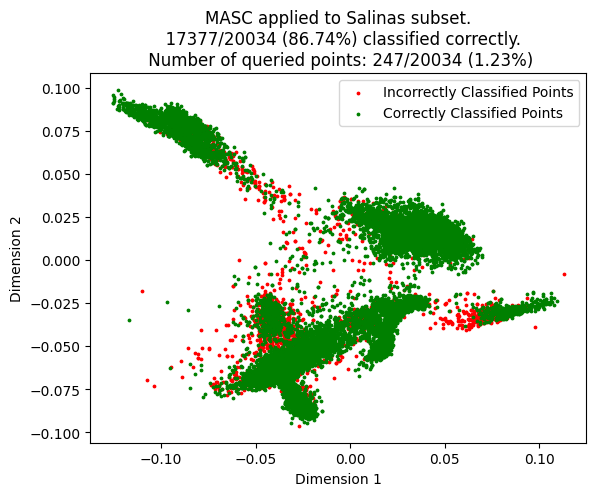

In [16]:
plt.scatter(trainsph[np.where(truthcheck3==False)[0],1],trainsph[np.where(truthcheck3==False)[0],2],s=3,color="r",label=f"Incorrectly Classified Points")
plt.scatter(trainsph[np.where(truthcheck3)[0],1],trainsph[np.where(truthcheck3)[0],2],color="g",s=3,label=f"Correctly Classified Points")
plt.title(f'MASC applied to Salinas subset.\n  {correctnum3}/{trainsize} ({100*correctnum3/trainsize:.2f}%) classified correctly.\n Number of queried points: {len(A)}/{trainsize} ({100*(len(A)/trainsize):.2f}%)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()

# Show the plot
plt.show()

Generate confusion matrix.

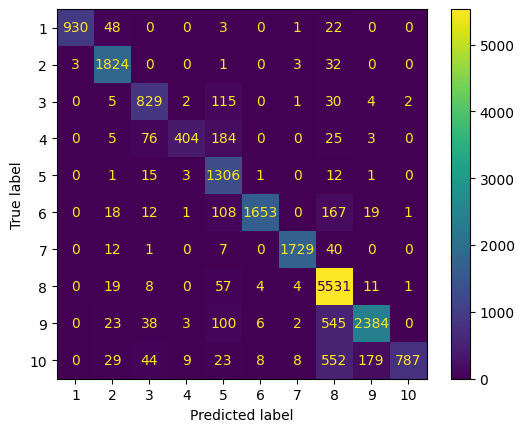

In [17]:
conf_matrix=metrics.confusion_matrix(target,labels)
disp=metrics.ConfusionMatrixDisplay(conf_matrix,display_labels=classes.astype(int))
disp.plot()

Generate predicted labels scatterplot.

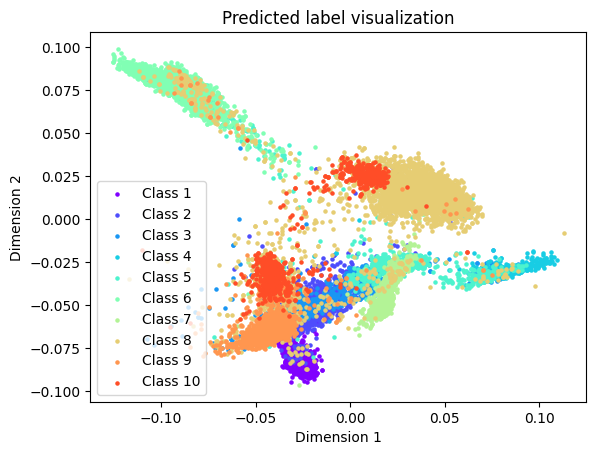

In [18]:
c=cm.rainbow(np.linspace(0,1,len(classes)+1))
for i in classes:
    plt.scatter(trainsph[np.where(labels==i)[0],1],trainsph[np.where(labels==i)[0],2],s=5,color=c[i-1],label=f"Class {i}")
plt.title('Predicted label visualization')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()

# Show the plot
plt.show()